In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# Load the iris dataset
data = load_iris()
X = data.data
y = data.target
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create a Logistic Regression model        
model = LogisticRegression(max_iter=200)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


## LR from Scratch 

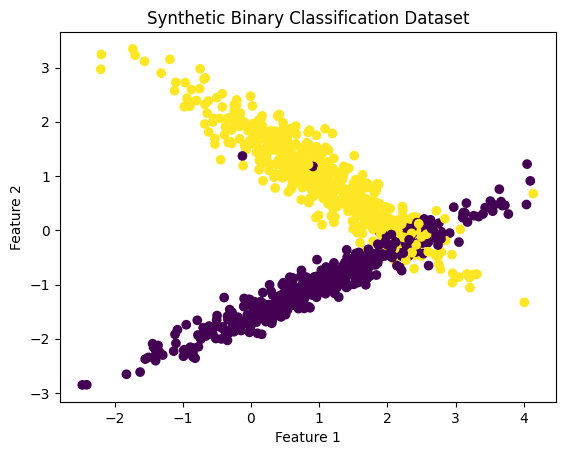

In [4]:
# lets implement LR from scratch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification    
# Generate a synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Synthetic Binary Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [5]:
# define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# define logistic regression class
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent
        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)
    

    

In [6]:
# lets train and evaluate our scratch model
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create a Logistic Regression model from scratch        
model_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000)
# Train the model
model_scratch.fit(X_train, y_train)
# Make predictions
y_pred_scratch = model_scratch.predict(X_test)
# Evaluate the model
accuracy_scratch = accuracy_score(y_test, y_pred_scratch)
print(f"Scratch Model Accuracy: {accuracy_scratch * 100:.2f}%")

Scratch Model Accuracy: 90.00%
